# 05 — Ajuste de distribuições e aderência (`fitting`)

Origem: script 12. O produto principal deste módulo é o **ENL**, que entra em `fit_model`, `cross_validation` e `likelihood_raster`.

## Estrutura

| Função | Descrição |
|---|---|
| `ks_test(x, distribution, params, ENL)` | KS contra **qualquer** distribuição univariada do catálogo com `cdf` |
| `fit_and_test(df, classes, distribution, ENL, method, significance_level)` | ajuste + KS por classe |
| `plot_fit(x, distribution, params, ENL, title)` | histograma + densidade ajustada |
| `gamma_fitting`, `gamma_fitting_fixed_enl`, `normal_fitting` | atalhos de `fit_and_test` com as colunas do original |
| `best_enl`, `iterative_gamma_fitting` | escolha do ENL |
| `mardia_test`, `normal_fitting_mv` | normalidade multivariada |

<details><summary><b>Correções em relação ao R</b></summary>

| Ponto | R original | Python |
|---|---|---|
| p-valores do Mardia | lidos por `levels()`, que ordena alfabeticamente, e podiam vir trocados | lidos pelo nome |
| Tipos da tabela | `rbind(c(...))` convertia números em texto | numéricos |
| Ajuste com ENL fixo | colunas `Shape`/`Rate` | `Alpha`/`Beta`, como no ajuste livre |
| Histograma | `binwidth = 0.01` fixo | `bins='auto'` |

O teste de Mardia é uma implementação própria da formulação do pacote `MVN`, que não estava disponível para comparação direta; foi validado por simulação.
</details>

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))   # pasta que contém sar_classification

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sar_classification import (distributions as dist, samples as smp, models as mdl,
                                raster_io as rio, separability as sep, validation as val,
                                fitting as fit, plots, diagnostics as diag)

In [2]:
# Dados fictícios gerados pelo próprio catálogo (substitua pelos seus df_samples)
rng = np.random.default_rng(42)
classes = ['F', 'VS', 'PA', 'SE']

def simulate(distribution, params_by_class, n, columns, ENL=None):
    parts = [pd.DataFrame(dist.get_distribution(distribution)['sample'](n, p, ENL, rng), columns=columns).assign(Class=c)
             for c, p in params_by_class.items()]
    return pd.concat(parts, ignore_index=True)[['Class'] + columns]

def random_cov(scale):
    A = rng.normal(0, scale, (3, 3))
    return A @ A.T + 1e-4 * np.eye(3)

df_gauss = simulate('gaussian', {c: {'mean': np.array(m), 'covariance_matrix': random_cov(0.02)} for c, m in
                    {'F': [0.20, 0.05, 0.30], 'VS': [0.22, 0.07, 0.28], 'PA': [0.10, 0.15, 0.20], 'SE': [0.05, 0.25, 0.10]}.items()},
                    120, ['B1', 'B2', 'B3'])
df_gamma = simulate('gamma', {c: {'alpha': 3.0, 'beta': 3.0 / mu} for c, mu in
                    {'F': 0.08, 'VS': 0.06, 'PA': 0.03, 'SE': 0.015}.items()}, 150, ['HH'], ENL=3)
df_pair = simulate('intensity_joint_distribution', {c: {'mu1': a, 'mu2': b, 'ro2': r} for c, (a, b, r) in
                   {'F': (0.08, 0.020, 0.25), 'VS': (0.06, 0.012, 0.16), 'PA': (0.03, 0.006, 0.09), 'SE': (0.015, 0.004, 0.49)}.items()},
                   150, ['HH', 'HV'], ENL=4)
print(df_gauss.shape, df_gamma.shape, df_pair.shape)

(480, 4) (600, 2) (600, 3)


## 1. Teste KS

$D = \sup_x|F_n(x) - F(x;\hat\theta)|$, com o p-valor seguindo a regra do `ks.test` do R: **exato** se $n < 100$ sem empates, e **assintótico** caso contrário.

> **Limitação metodológica (mantida):** como os parâmetros são estimados nos próprios dados testados, o KS fica **conservador** e tende a aceitar H0 (problema de Lilliefors). Os p-valores devem ser lidos como indicativos.

In [3]:
free = fit.gamma_fitting(df_gamma, classes, verbose=False)
free.round(5)

,Class,Alpha,Beta,D,p_value,H0
0,F,2.58584,33.68319,0.06122,0.62762,accept
1,VS,2.61292,47.07734,0.04684,0.89717,accept
2,PA,2.74796,83.56722,0.05015,0.84494,accept
3,SE,3.05985,197.63405,0.04335,0.94063,accept


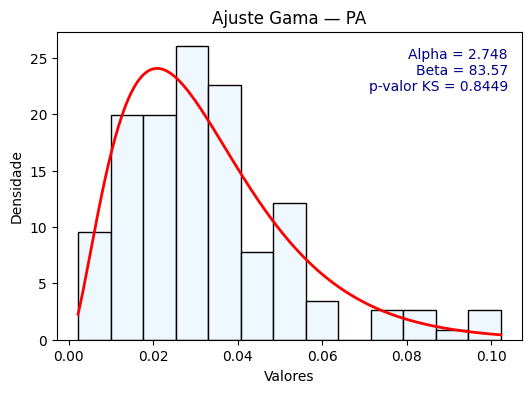

In [4]:
x_pa = df_gamma.loc[df_gamma['Class'] == 'PA', ['HH']]
params_pa = dist.get_distribution('gamma')['fit'](x_pa.to_numpy(), method='mle')
fit.plot_fit(x_pa, 'gamma', params_pa, title='Ajuste Gama — PA')

## 2. Escolha do ENL — `iterative_gamma_fitting`

1. Ajuste livre em cada classe; os candidatos são os $\hat\alpha$ das classes que aceitaram H0, em ordem decrescente de p-valor.
2. Para cada candidato, testa a Gama com $\alpha$ = candidato em **todas** as classes.
3. Vence o candidato com mais classes aceitas. Em caso de empate, vence o primeiro da ordem do passo 1.

Retorno: `best_enl`, `fitting_result` (do vencedor), `result_counting` e `free_fit`.

> Quando todos os candidatos empatam no passo 3, a escolha passa a ser feita só pelo desempate. Vale conferir `result_counting` nos dados reais.

In [5]:
enl = fit.iterative_gamma_fitting(df_gamma, classes, verbose=False)
print(f"ENL = {enl['best_enl']:.4f}")
enl['result_counting']

ENL = 3.0599


,ENL,Count
0,3.059854,4
1,2.612919,4
2,2.747959,4
3,2.585842,4


## 3. Normal univariada

`normal_fitting` ajusta por MV ($\hat\sigma$ com denominador $n$) e exige um único atributo, por exemplo `df[['Class', 'B1']]`.

In [6]:
fit.normal_fitting(df_gauss[['Class', 'B1']], classes, verbose=False).round(5)

,Class,Mean,SD,D,p_value,H0
0,F,0.19883,0.02647,0.05727,0.82611,accept
1,VS,0.22276,0.03347,0.08516,0.34894,accept
2,PA,0.09790,0.01913,0.05685,0.83275,accept
3,SE,0.04969,0.01806,0.04853,0.94005,accept


## 4. Mardia

Com $\mathbf{S}$ de denominador $n$ e $d_{ij} = (\mathbf{x}_i-\bar{\mathbf{x}})^\intercal\mathbf{S}^{-1}(\mathbf{x}_j-\bar{\mathbf{x}})$:

$$b_{1,p} = \tfrac{1}{n^2}\textstyle\sum_{i,j}d_{ij}^3, \qquad b_{2,p} = \tfrac{1}{n}\textstyle\sum_i d_{ii}^2$$

| Estatística | Distribuição sob H0 |
|---|---|
| $n\,b_{1,p}/6$ (com correção de pequenas amostras se $n<20$) | $\chi^2$ com $p(p+1)(p+2)/6$ g.l. |
| $(b_{2,p}-p(p+2))\sqrt{n/(8p(p+2))}$ | $N(0,1)$, bilateral |

H0 é aceita se **os dois** p-valores forem maiores que `significance_level`.

In [7]:
print('Dados gaussianos:'); print(fit.normal_fitting_mv(df_gauss, classes).round(4).to_string(index=False))
print('\nPar de intensidades (não gaussiano):'); print(fit.normal_fitting_mv(df_pair, classes).round(4).to_string(index=False))

Dados gaussianos:
Class  skewness  p_value_skewness  kurtosis  p_value_kurtosis     H0
    F   10.9872            0.3585    0.5660            0.5714 accept
   VS   11.8131            0.2978   -0.8806            0.3785 accept
   PA   20.7933            0.0226    2.0019            0.0453 reject
   SE   13.3250            0.2061   -0.4584            0.6467 accept

Par de intensidades (não gaussiano):


Class  skewness  p_value_skewness  kurtosis  p_value_kurtosis     H0
    F   26.3476               0.0   -0.3124            0.7548 reject
   VS   71.2446               0.0    6.5902            0.0000 reject
   PA   28.3493               0.0    0.1464            0.8836 reject
   SE   55.6220               0.0    4.9077            0.0000 reject
